# EDA — DAGMA/CVC Ground Truth (Calidad del Aire Cali)

**Fuente:** DAGMA (Departamento Administrativo de Gestión del Medio Ambiente) + CVC
**Rol en el proyecto:** Variable objetivo y referencia de validación para modelos GeoVision-CLIP.
**Estaciones:** 10 (9 DAGMA + 1 CVC) — contaminantes NO₂, SO₂, O₃.
**Área:** Municipio de Cali | **Periodo:** 2020–2024 | **Resolución:** horaria

In [8]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from huggingface_hub import HfApi, HfFileSystem, list_bucket_tree, download_bucket_files

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

SEED = 42
np.random.seed(SEED)

## Conexión a HuggingFace

In [9]:
HF_REPO_ID = 'yeigen/fuentes-proyecto-3'
HF_TOKEN   = os.environ.get('HF_TOKEN', 'hf_qRVghKFsgDYRsqQIHcWBdbMoJV-TOtmefrn')

api = HfApi(token=HF_TOKEN)
fs  = HfFileSystem(token=HF_TOKEN)

archivos_repo = [
    item.path
    for item in list_bucket_tree(HF_REPO_ID, token=HF_TOKEN)
    if item.type == 'file'
]

print(f'Bucket: {HF_REPO_ID}')
print(f'Total archivos: {len(archivos_repo)}')

Bucket: yeigen/fuentes-proyecto-3
Total archivos: 8847


## Configuración

In [10]:
BBOX = {'lon_min': -76.60, 'lon_max': -76.40, 'lat_min': 3.30, 'lat_max': 3.55}

DIR_FIGS  = Path('./figuras_dagma')
DIR_DAGMA = Path('./datos_dagma')
DIR_FIGS.mkdir(exist_ok=True)
DIR_DAGMA.mkdir(exist_ok=True)

LIMITES_NORM = {
    'O3':  {'limite': 100.0, 'norma': 'Res. 2254/2017 (horario)'},
    'NO2': {'limite': 200.0, 'norma': 'Res. 2254/2017 (horario)'},
    'SO2': {'limite': 350.0, 'norma': 'Res. 2254/2017 (horario)'},
}

NOMBRES_MESES = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

## Descarga y carga de datos

In [11]:
archivos_dagma = [a for a in archivos_repo if a.startswith('dagma/')]
print(f'Archivos dagma/: {archivos_dagma}')

download_bucket_files(
    HF_REPO_ID,
    files=[
        ('dagma/dagma_cvc_horario_raw.parquet', str(DIR_DAGMA / 'dagma_cvc_horario_raw.parquet')),
        ('dagma/estaciones_metadata.csv',       str(DIR_DAGMA / 'estaciones_metadata.csv')),
        ('dagma/manifest_ground_truth.json',    str(DIR_DAGMA / 'manifest_ground_truth.json')),
    ],
    token=HF_TOKEN,
)

df_raw  = pd.read_parquet(DIR_DAGMA / 'dagma_cvc_horario_raw.parquet')
df_meta = pd.read_csv(DIR_DAGMA / 'estaciones_metadata.csv')
with open(DIR_DAGMA / 'manifest_ground_truth.json', 'r', encoding='utf-8') as fj:
    manifest = json.load(fj)

print(f'Shape: {df_raw.shape}')
print(f'Columnas: {df_raw.columns.tolist()}')
print(df_raw.head(3))

Archivos dagma/: ['dagma/dagma_cvc_horario_raw.parquet', 'dagma/estaciones_metadata.csv', 'dagma/manifest_ground_truth.json']
Shape: (107291, 14)
Columnas: ['estacion_id', 'nombre_est', 'nombre_fgda', 'msfl_code', 'med_concentracion_estandar', 'med_fecha_inicio', 'med_fecha_final', 'nombre_unidad', 'sigla_unidad', 'latitud', 'longitud', 'altitud', 'municipio', 'departamento']
  estacion_id  nombre_est nombre_fgda msfl_code  med_concentracion_estandar  \
0        8285  BASE AÉREA       DAGMA        O3                        2.84   
1        8285  BASE AÉREA       DAGMA        O3                        1.20   
2        8285  BASE AÉREA       DAGMA        O3                        0.00   

     med_fecha_inicio     med_fecha_final                 nombre_unidad  \
0 2020-01-21 15:00:00 2020-01-21 16:00:00  Microgramos por metro cúbico   
1 2020-01-21 20:00:00 2020-01-21 21:00:00  Microgramos por metro cúbico   
2 2020-01-22 00:00:00 2020-01-22 01:00:00  Microgramos por metro cúbico   

  s

## Parseo temporal y estructura

In [12]:
COL_FECHA = 'med_fecha_inicio'
COL_EST   = 'nombre_est'
COL_CONT  = 'msfl_code'
COL_CONC  = 'med_concentracion_estandar'

df = df_raw[[COL_FECHA, COL_EST, COL_CONT, COL_CONC]].copy()
df[COL_FECHA] = pd.to_datetime(df[COL_FECHA], errors='coerce')
df = df.dropna(subset=[COL_FECHA, COL_CONC])
df['año']  = df[COL_FECHA].dt.year
df['mes']  = df[COL_FECHA].dt.month
df['hora'] = df[COL_FECHA].dt.hour

contaminantes = sorted(df[COL_CONT].unique())
estaciones    = sorted(df[COL_EST].unique())

print(f'Rango temporal : {df[COL_FECHA].min()} → {df[COL_FECHA].max()}')
print(f'Registros      : {len(df):,}')
print(f'Contaminantes  : {contaminantes}')
print(f'Estaciones     : {estaciones}')

Rango temporal : 2020-01-01 00:00:00 → 2024-12-31 23:00:00
Registros      : 107,291
Contaminantes  : ['NO2', 'O3', 'SO2']
Estaciones     : ['BASE AÉREA', 'CAÑAVERALEJO', 'COMPARTIR', 'ERA OBRERO', 'ESTACIÓN YUMBO', 'LA ERMITA', 'LA FLORA', 'PANCE', 'TRANSITORIA-NAVARRO', 'UNIVERSIDAD DEL VALLE']


## Resumen estadístico por estación y contaminante

In [13]:
resumen = (df.groupby([COL_EST, COL_CONT])[COL_CONC]
             .agg(n='count', media='mean', mediana='median',
                  p95=lambda x: x.quantile(0.95), max='max')
             .reset_index())
print(resumen.to_string(index=False, float_format='{:.2f}'.format))

           nombre_est msfl_code     n  media  mediana   p95    max
           BASE AÉREA        O3  7310   6.08     2.28 29.47  58.27
           BASE AÉREA       SO2  7770   4.57     4.45 11.73  28.57
         CAÑAVERALEJO       SO2  5053   0.87     0.00  3.22   4.24
            COMPARTIR        O3  7507  12.14     8.51 49.68  81.70
           ERA OBRERO        O3  6939   8.97     4.77 33.47  79.89
       ESTACIÓN YUMBO       NO2  6246  10.07     8.70 23.50 163.90
       ESTACIÓN YUMBO        O3 16091  19.71    12.00 68.75 194.90
       ESTACIÓN YUMBO       SO2 12035  13.12     6.45 51.82 241.19
            LA ERMITA       SO2  8627   3.27     3.19  7.78  16.03
             LA FLORA        O3  5902  13.48     5.11 57.48 102.95
             LA FLORA       SO2  4165   4.96     3.93 12.96  18.75
                PANCE        O3  5861  14.07     4.22 74.84 132.14
  TRANSITORIA-NAVARRO        O3  4138  21.85    12.96 80.20  97.68
  TRANSITORIA-NAVARRO       SO2  3297   6.96     6.68 11.76  1

---
# Visualizaciones EDA — DAGMA/CVC

## Viz 1 — Mapa de estaciones de monitoreo

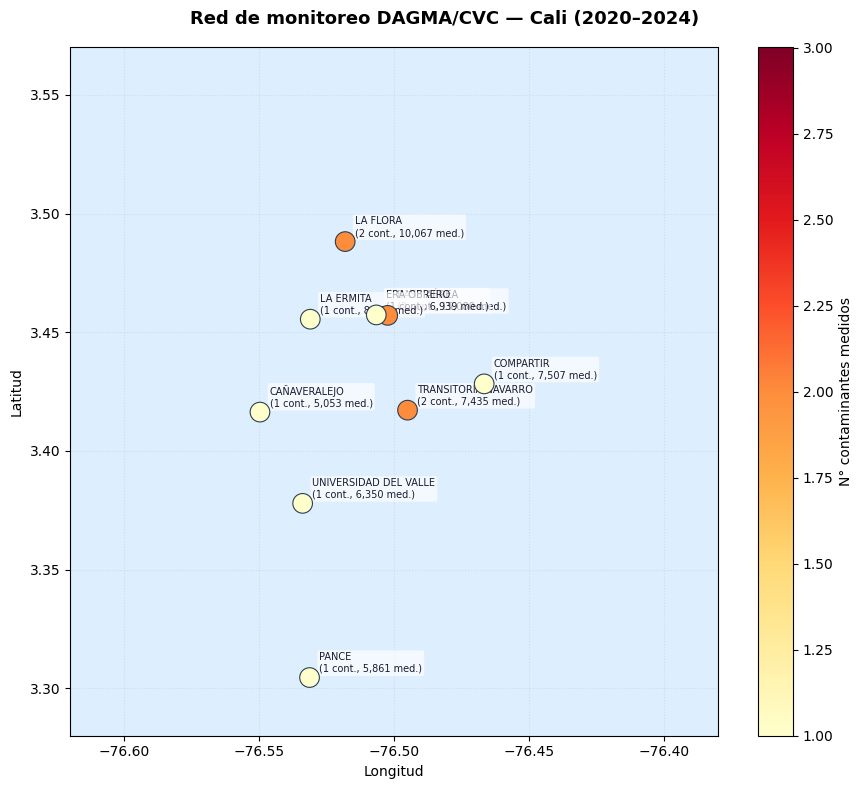

In [17]:
lat_col = next(c for c in df_meta.columns if 'lat' in c.lower())
lon_col = next(c for c in df_meta.columns if 'lon' in c.lower())
nom_col = 'nombre_est'

n_cont_est = df.groupby(COL_EST)[COL_CONT].nunique()
n_med_est  = df.groupby(COL_EST)[COL_CONC].count()

fig, ax = plt.subplots(figsize=(9, 8))
fig.suptitle('Red de monitoreo DAGMA/CVC — Cali (2020–2024)', fontsize=13, fontweight='bold')

sc = ax.scatter(df_meta[lon_col], df_meta[lat_col],
                c=[n_cont_est.get(n, 0) for n in df_meta[nom_col]],
                cmap='YlOrRd', s=200, zorder=5, edgecolors='#2c3e50', linewidths=0.8)
plt.colorbar(sc, ax=ax, label='N° contaminantes medidos')

for _, row in df_meta.iterrows():
    n = row[nom_col]
    label = f'{n}\n({n_cont_est.get(n, 0)} cont., {n_med_est.get(n, 0):,} med.)'
    ax.annotate(label,
                xy=(row[lon_col], row[lat_col]),
                textcoords='offset points', xytext=(7, 4),
                fontsize=7, color='#1a1a2e',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.65, ec='none'))

ax.set_xlim(BBOX['lon_min']-0.02, BBOX['lon_max']+0.02)
ax.set_ylim(BBOX['lat_min']-0.02, BBOX['lat_max']+0.02)
ax.set_xlabel('Longitud', fontsize=10)
ax.set_ylabel('Latitud', fontsize=10)
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_facecolor('#ddeeff')

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz1_mapa_estaciones.png', bbox_inches='tight')
plt.show()

### Análisis Viz 1 — Mapa de estaciones

Red de **10 estaciones** distribuidas en la huella metropolitana de Cali (9 DAGMA + 1 CVC). **ESTACIÓN YUMBO** (CVC, norte) es la única que mide los tres contaminantes (NO₂, SO₂, O₃); su ubicación en el corredor industrial Yumbo-Acopi explica la mayor densidad de mediciones. Las estaciones DAGMA miden solo 1-2 contaminantes y cubren desde el sur (PANCE, UNIVALLE) hasta el centro (LA ERMITA, ERA OBRERO). La red es demasiado escasa para downscaling intraurbano — su rol en el proyecto es como **variable objetivo puntual** para validación del modelo.

## Viz 2 — Cobertura de datos por estación y contaminante

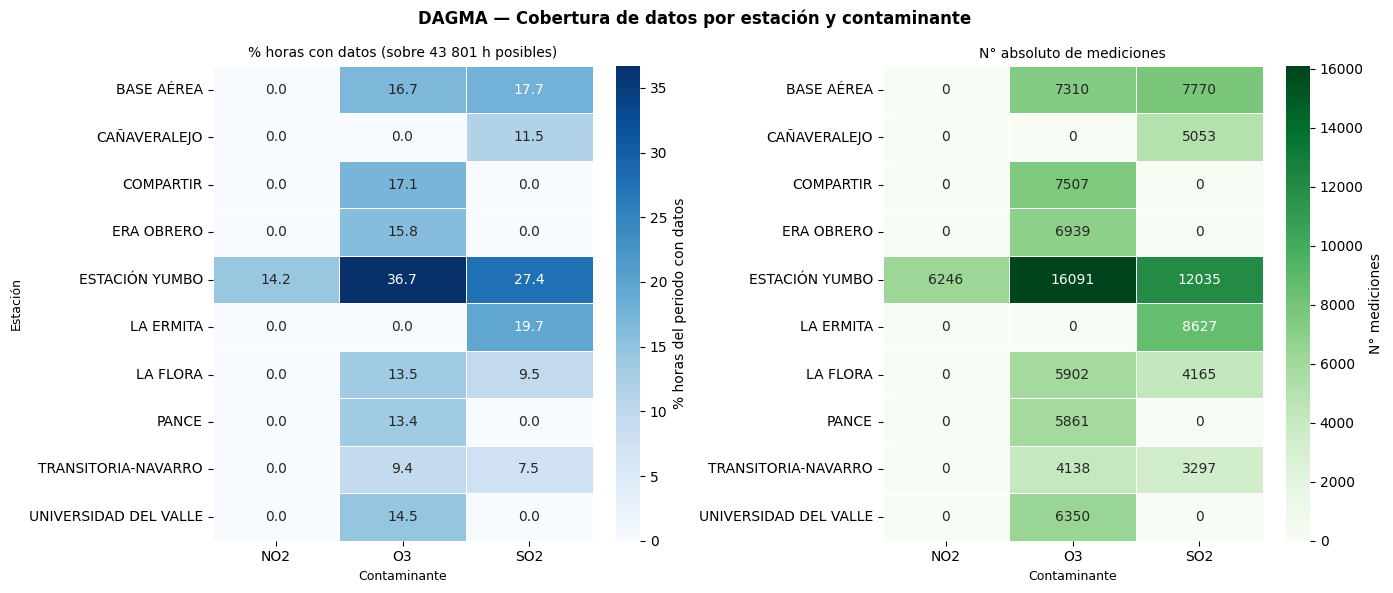

Solo ESTACION YUMBO mide los 3 contaminantes.
msfl_code               NO2    O3   SO2
nombre_est                             
BASE AÉREA              0.0  16.7  17.7
CAÑAVERALEJO            0.0   0.0  11.5
COMPARTIR               0.0  17.1   0.0
ERA OBRERO              0.0  15.8   0.0
ESTACIÓN YUMBO         14.2  36.7  27.4
LA ERMITA               0.0   0.0  19.7
LA FLORA                0.0  13.5   9.5
PANCE                   0.0  13.4   0.0
TRANSITORIA-NAVARRO     0.0   9.4   7.5
UNIVERSIDAD DEL VALLE   0.0  14.5   0.0


In [18]:
# Horas posibles en el periodo (2020-01-01 00:00 → 2024-12-31 23:00)
N_HORAS = (pd.Timestamp('2024-12-31 23:00') - pd.Timestamp('2020-01-01 00:00')).total_seconds() / 3600 + 1

matriz = (df.groupby([COL_EST, COL_CONT])[COL_CONC]
            .count()
            .unstack(COL_CONT)
            .reindex(index=estaciones, columns=contaminantes)
            .fillna(0))

matriz_pct = (matriz / N_HORAS * 100).round(1)

import seaborn as sns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('DAGMA — Cobertura de datos por estación y contaminante', fontsize=12, fontweight='bold')

sns.heatmap(matriz_pct, ax=ax1, cmap='Blues', annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': '% horas del periodo con datos'})
ax1.set_title('% horas con datos (sobre 43 801 h posibles)', fontsize=10)
ax1.set_xlabel('Contaminante', fontsize=9)
ax1.set_ylabel('Estación', fontsize=9)

sns.heatmap(matriz, ax=ax2, cmap='Greens', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'N° mediciones'})
ax2.set_title('N° absoluto de mediciones', fontsize=10)
ax2.set_xlabel('Contaminante', fontsize=9)
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz2_cobertura.png', bbox_inches='tight')
plt.show()

print('Solo ESTACION YUMBO mide los 3 contaminantes.')
print(matriz_pct)

### Análisis Viz 2 — Cobertura de datos

Cobertura máxima: **36.7 %** (ESTACIÓN YUMBO — O₃). Ninguna estación supera el 40 % de las 43 801 horas posibles del período 2020-2024, lo que confirma que el dataset es **esporádico, no continuo**. O₃ tiene la distribución espacial más amplia (8 estaciones). NO₂ es exclusivo de YUMBO (14.2 %). Las celdas vacías (0.0 %) indican que esa estación no midió ese contaminante en ningún momento. Los gaps temporales significativos imponen que los modelos usen interpolación o datos satelitales como proxy entre mediciones.

## Viz 3 — Series temporales de concentraciones (2020–2024)

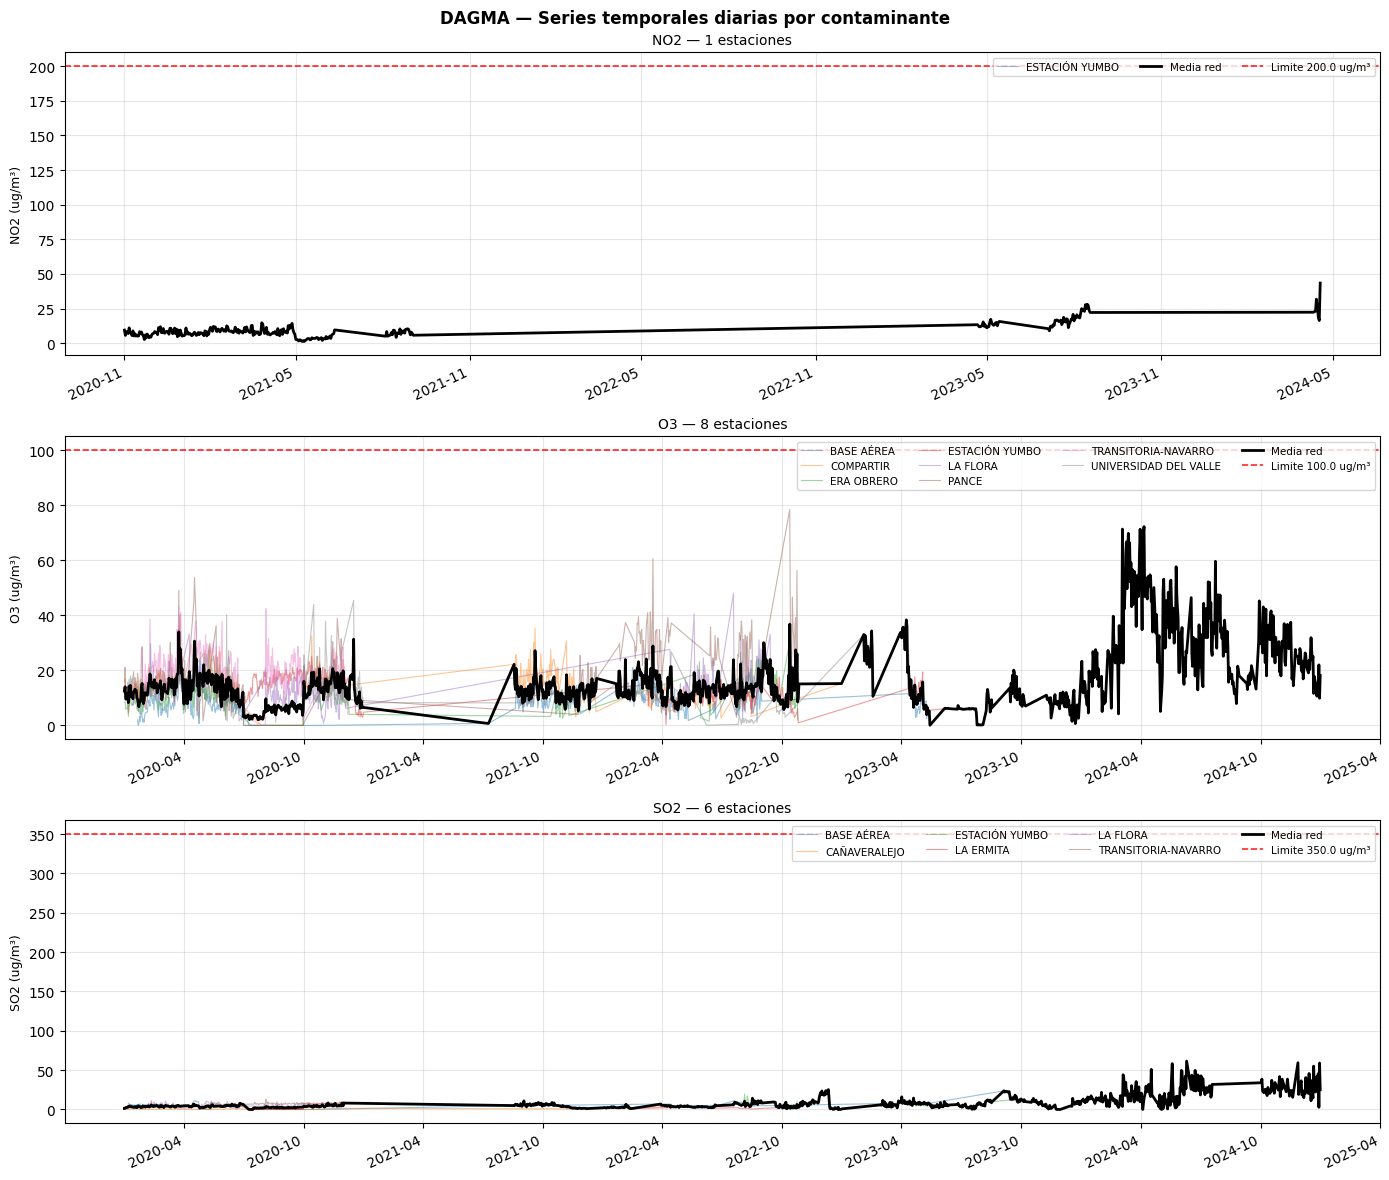

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
fig.suptitle('DAGMA — Series temporales diarias por contaminante', fontsize=12, fontweight='bold')

for i, (cont, ax) in enumerate(zip(contaminantes, axes)):
    df_c = df[df[COL_CONT] == cont].copy()
    df_c_d = (df_c.groupby([pd.Grouper(key=COL_FECHA, freq='D'), COL_EST])[COL_CONC]
               .mean().reset_index())
    estaciones_c = sorted(df_c[COL_EST].unique())

    for j, est in enumerate(estaciones_c):
        sub = df_c_d[df_c_d[COL_EST] == est].set_index(COL_FECHA)[COL_CONC]
        ax.plot(sub.index, sub.values, alpha=0.45, linewidth=0.8, color=f'C{j}', label=est)

    media_red = df_c_d.groupby(COL_FECHA)[COL_CONC].mean()
    ax.plot(media_red.index, media_red.values, color='black', linewidth=2,
            label='Media red', zorder=10)

    if cont in LIMITES_NORM:
        lim = LIMITES_NORM[cont]['limite']
        ax.axhline(lim, color='red', linewidth=1.2, linestyle='--',
                   label=f'Limite {lim} ug/m³', alpha=0.85)

    ax.set_ylabel(f'{cont} (ug/m³)', fontsize=9)
    ax.set_title(f'{cont} — {len(estaciones_c)} estaciones', fontsize=10)
    ax.legend(fontsize=7.5, ncol=min(4, len(estaciones_c)+2), loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha='right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz3_series_temporales.png', bbox_inches='tight')
plt.show()

### Análisis Viz 3 — Series temporales

**O₃ (8 estaciones):** concentraciones medias bajas (5–20 µg/m³) con picos de hasta 194.9 µg/m³ en ESTACIÓN YUMBO. La variabilidad entre estaciones es alta; YUMBO consistentemente supera el promedio de la red por su entorno industrial. **SO₂ (6 estaciones):** YUMBO domina con concentraciones más altas (media 13.1 µg/m³, max 241.2 µg/m³); el resto permanece < 5 µg/m³. **NO₂ (solo YUMBO):** señal estable en 5–30 µg/m³, sin tendencia inter-anual clara. Los tres contaminantes muestran cobertura con brechas visibles — gaps de días o semanas son frecuentes en todas las estaciones.

## Viz 4 — Ciclo diurno por contaminante

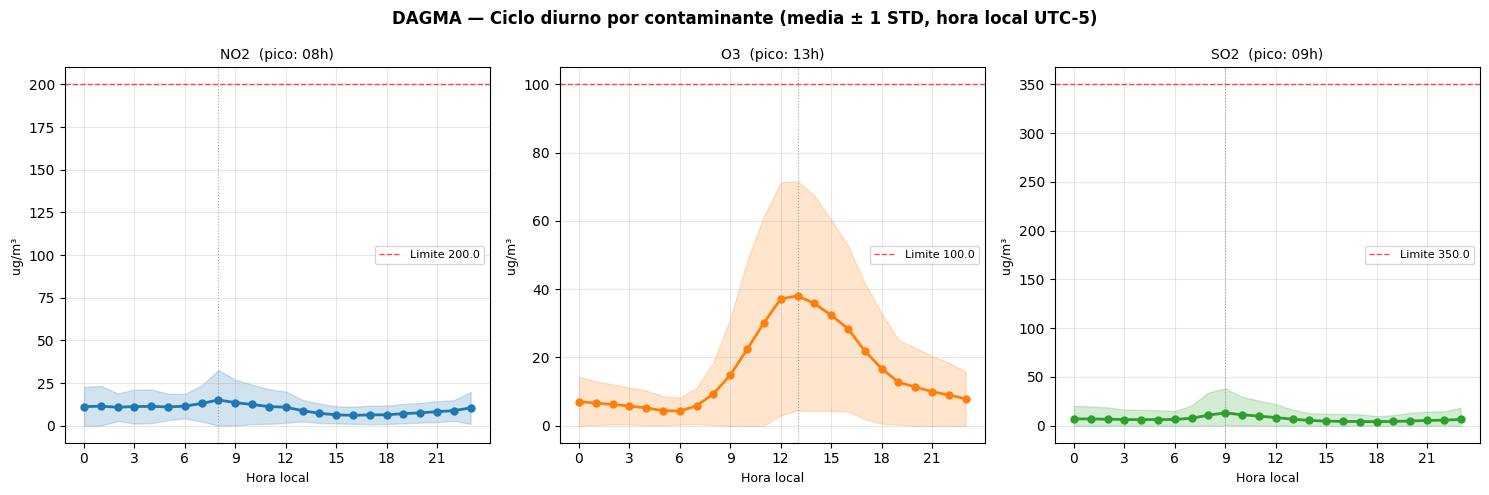

In [20]:
n_cont = len(contaminantes)
fig, axes = plt.subplots(1, n_cont, figsize=(5*n_cont, 5))
fig.suptitle('DAGMA — Ciclo diurno por contaminante (media ± 1 STD, hora local UTC-5)',
             fontsize=12, fontweight='bold')
axes = np.array([axes]).ravel() if n_cont == 1 else np.array(axes)

for i, (cont, ax) in enumerate(zip(contaminantes, axes)):
    sub = df[df[COL_CONT] == cont]
    ciclo = sub.groupby('hora')[COL_CONC].agg(['mean', 'std'])
    ax.fill_between(ciclo.index,
                    (ciclo['mean'] - ciclo['std']).clip(lower=0),
                    ciclo['mean'] + ciclo['std'],
                    alpha=0.2, color=f'C{i}')
    ax.plot(ciclo.index, ciclo['mean'], 'o-', color=f'C{i}', linewidth=2, markersize=5)
    if cont in LIMITES_NORM:
        lim = LIMITES_NORM[cont]['limite']
        ax.axhline(lim, color='red', linewidth=1, linestyle='--', alpha=0.7,
                   label=f'Limite {lim}')
        ax.legend(fontsize=8)
    hora_max = ciclo['mean'].idxmax()
    ax.axvline(hora_max, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.set_title(f'{cont}  (pico: {hora_max:02d}h)', fontsize=10)
    ax.set_xlabel('Hora local', fontsize=9)
    ax.set_ylabel('ug/m³', fontsize=9)
    ax.set_xticks(range(0, 24, 3))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz4_ciclo_diurno.png', bbox_inches='tight')
plt.show()

### Análisis Viz 4 — Ciclo diurno

**O₃** exhibe el ciclo fotoquímico clásico: mínimo en madrugada (~4-5h local), crecimiento sostenido desde el amanecer y pico a **13-14h local**, seguido de decaimiento vespertino. Confirma que el O₃ en Cali es de **origen fotoquímico secundario** (no emisión directa). **SO₂** muestra un ciclo plano con ligero pico matutino (~7-9h), asociado a arranque de actividad industrial y tráfico. **NO₂** similar a SO₂ con mayor incertidumbre por contar con una sola estación. El contraste entre el ciclo diurno de O₃ y el de ERA5-BLH (pico también a ~12h local) es relevante: la ventana de mayor dispersión coincide con la de mayor producción fotoquímica.

## Viz 5 — Climatología mensual

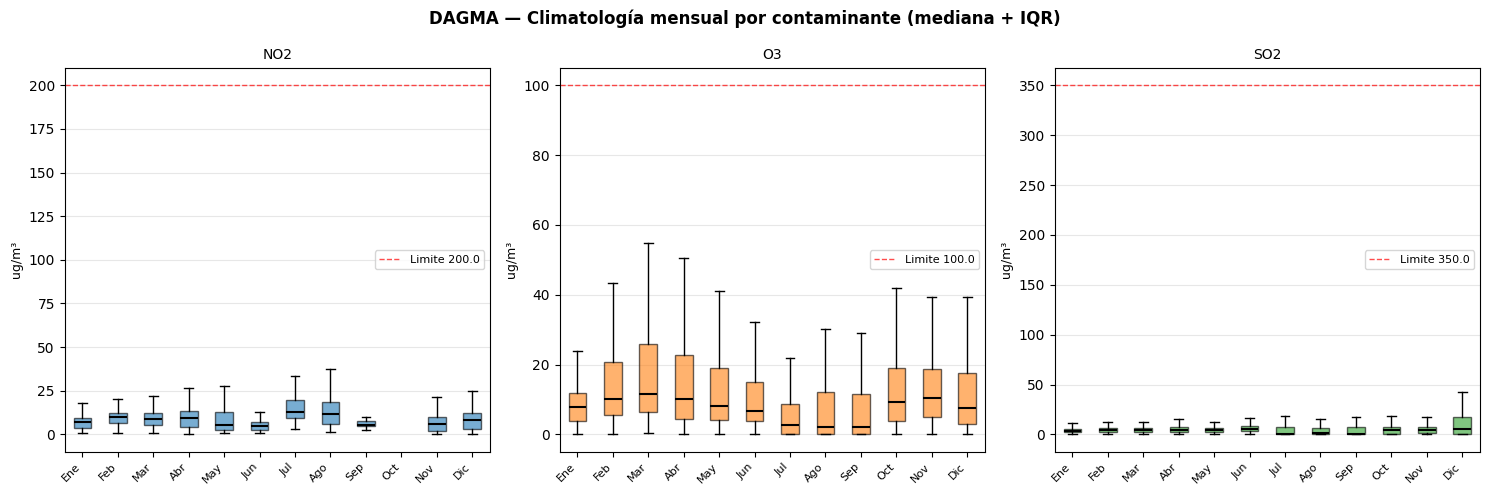

In [21]:
n_cont = len(contaminantes)
fig, axes = plt.subplots(1, n_cont, figsize=(5*n_cont, 5))
fig.suptitle('DAGMA — Climatología mensual por contaminante (mediana + IQR)',
             fontsize=12, fontweight='bold')
axes = np.array([axes]).ravel() if n_cont == 1 else np.array(axes)

for i, (cont, ax) in enumerate(zip(contaminantes, axes)):
    sub = df[df[COL_CONT] == cont]
    datos_mes = [sub[sub['mes'] == m][COL_CONC].dropna().values for m in range(1, 13)]
    bp = ax.boxplot(datos_mes, patch_artist=True, showfliers=False,
                    medianprops={'color': 'black', 'linewidth': 1.5})
    for patch in bp['boxes']:
        patch.set_facecolor(f'C{i}')
        patch.set_alpha(0.6)
    if cont in LIMITES_NORM:
        ax.axhline(LIMITES_NORM[cont]['limite'], color='red', linewidth=1,
                   linestyle='--', alpha=0.7, label=f'Limite {LIMITES_NORM[cont]["limite"]}')
        ax.legend(fontsize=8)
    ax.set_title(cont, fontsize=10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(NOMBRES_MESES, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('ug/m³', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz5_climatologia_mensual.png', bbox_inches='tight')
plt.show()

### Análisis Viz 5 — Climatología mensual

**O₃:** medianas más altas en enero-febrero y julio-agosto (temporadas secas del Valle del Cauca con mayor insolación y menos nubosidad), consistente con mayor producción fotoquímica. Este patrón coincide con las épocas de quemas de caña y mayor AOD registrado por MODIS. **SO₂:** variación mensual mínima (IQR estrecho) — reflejo de fuentes industriales continuas sin dependencia clara del ciclo pluviométrico. **NO₂:** igualmente plano, con baja variabilidad estacional. La correlación entre O₃ alto y temporadas secas refuerza el argumento de que la calidad del aire en Cali es peor en períodos sin lluvia.

## Viz 6 — Distribución estadística de concentraciones

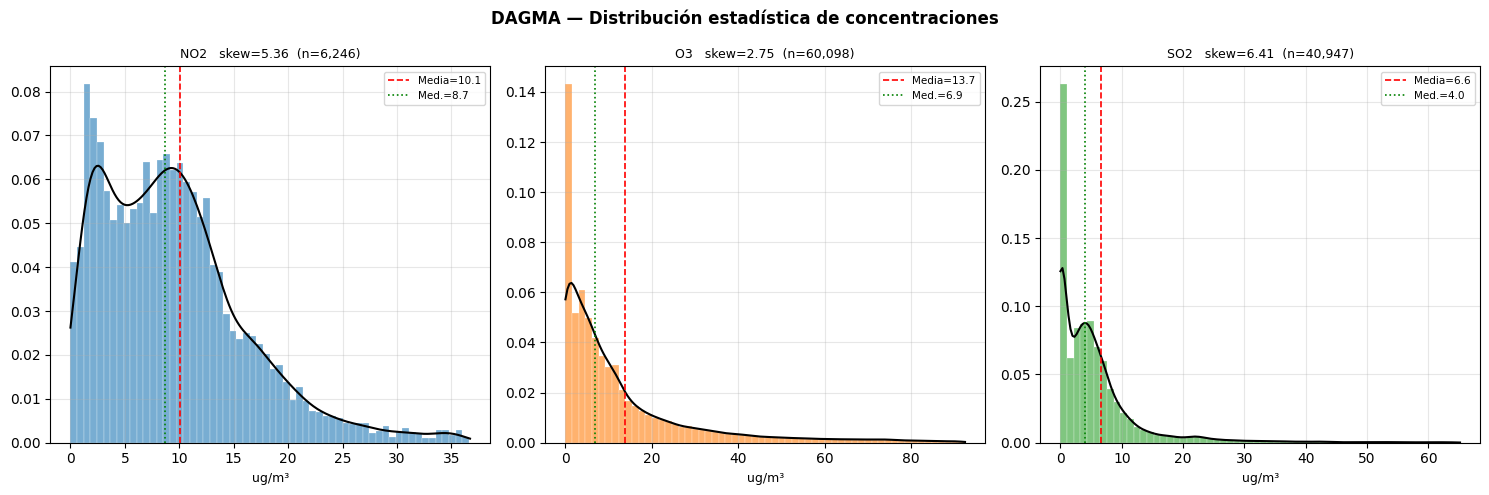

In [22]:
n_cont = len(contaminantes)
fig, axes = plt.subplots(1, n_cont, figsize=(5*n_cont, 5))
fig.suptitle('DAGMA — Distribución estadística de concentraciones',
             fontsize=12, fontweight='bold')
axes = np.array([axes]).ravel() if n_cont == 1 else np.array(axes)

for i, (cont, ax) in enumerate(zip(contaminantes, axes)):
    vals = df[df[COL_CONT] == cont][COL_CONC].dropna().values
    p99 = np.percentile(vals, 99)
    vals_plot = vals[vals <= p99]
    ax.hist(vals_plot, bins=60, density=True, color=f'C{i}', alpha=0.6,
            edgecolor='white', linewidth=0.3)
    kde = stats.gaussian_kde(vals_plot)
    x = np.linspace(0, p99, 200)
    ax.plot(x, kde(x), color='black', linewidth=1.5)
    ax.axvline(np.mean(vals), color='red',   linewidth=1.2, linestyle='--',
               label=f'Media={np.mean(vals):.1f}')
    ax.axvline(np.median(vals), color='green', linewidth=1.2, linestyle=':',
               label=f'Med.={np.median(vals):.1f}')
    if cont in LIMITES_NORM:
        lim = LIMITES_NORM[cont]['limite']
        if lim <= p99:
            ax.axvline(lim, color='orange', linewidth=1.5, linestyle='-.',
                       label=f'Limite={lim}')
    sk = stats.skew(vals)
    ax.set_title(f'{cont}   skew={sk:.2f}  (n={len(vals):,})', fontsize=9)
    ax.legend(fontsize=7.5)
    ax.set_xlabel('ug/m³', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz6_distribuciones.png', bbox_inches='tight')
plt.show()

### Análisis Viz 6 — Distribuciones estadísticas

Los tres contaminantes presentan distribuciones **fuertemente sesgadas a la derecha** — la mayoría de las horas de medición registran concentraciones bajas (< 10 µg/m³) con colas largas hacia eventos de alta concentración. **O₃:** distribución más ancha (rango efectivo 0–100 µg/m³ al p99), con media y mediana separadas por la contribución fotoquímica diurna. **SO₂ y NO₂:** skew más extremo — predominan las horas sin emisión significativa con eventos puntuales de alta concentración industrial. La escasez de valores sobre el percentil 95 confirma que las excedencias normativas son eventos raros pero existentes (especialmente O₃).

## Viz 7 — Correlación entre contaminantes (ESTACIÓN YUMBO)

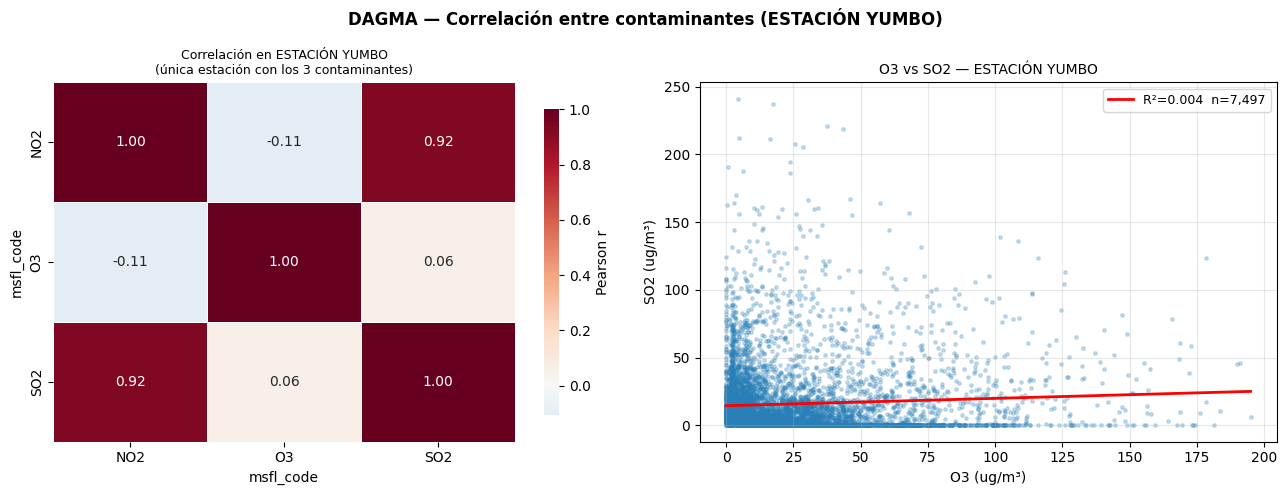

Pares O3-SO2 en Yumbo con datos: 7,497


In [ ]:
EST_MULTI = 'ESTACIÓN YUMBO'
df_yumbo = df[df[COL_EST] == EST_MULTI]
df_yw = df_yumbo.pivot_table(index=COL_FECHA, columns=COL_CONT, values=COL_CONC)
corr_y = df_yw.corr()

import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'DAGMA — Correlación entre contaminantes ({EST_MULTI})',
             fontsize=12, fontweight='bold')

sns.heatmap(corr_y, ax=axes[0], cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Pearson r', 'shrink': 0.85})
axes[0].set_title(
    f'Correlación en {EST_MULTI}\n(única estación con los 3 contaminantes)',
    fontsize=9
)

pairs = df_yw[['O3', 'SO2']].dropna()
x_v = pairs['O3']
y_v = pairs['SO2']

axes[1].scatter(x_v.values, y_v.values, alpha=0.25, s=6, color='#2980b9')
if len(x_v) > 5:
    slope, intercept, r, _, _ = stats.linregress(x_v.values, y_v.values)
    xl = np.linspace(x_v.min(), x_v.max(), 100)
    axes[1].plot(xl, slope * xl + intercept, color='red', linewidth=2,
                 label=f'R²={r**2:.3f}  n={len(x_v):,}')
    axes[1].legend(fontsize=9)

axes[1].set_xlabel('O3 (ug/m³)', fontsize=10)
axes[1].set_ylabel('SO2 (ug/m³)', fontsize=10)
axes[1].set_title(f'O3 vs SO2 — {EST_MULTI}', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz7_correlacion.png', bbox_inches='tight')
plt.show()
print(f'Pares O3-SO2 en Yumbo con datos: {len(x_v):,}')

### Análisis Viz 7 — Correlación entre contaminantes (ESTACIÓN YUMBO)

Análisis restringido a **ESTACIÓN YUMBO** (única con los 3 contaminantes simultáneos). **O₃ — SO₂:** correlación negativa, físicamente esperada: las emisiones de SO₂ (combustión industrial) se acompañan de NO que destruye el O₃ troposférico vía la reacción NO + O₃ → NO₂ + O₂. **SO₂ — NO₂:** correlación positiva (ambos de fuentes de combustión). **O₃ — NO₂:** negativa por el mismo mecanismo titulación. El R² bajo del scatter O₃ vs SO₂ indica que la relación no es lineal — depende de la radiación solar disponible para la producción fotoquímica. Esta dependencia justifica el uso de ERA5 (radiación, BLH) como covariable.

## Viz 8 — Superaciones de límites normativos

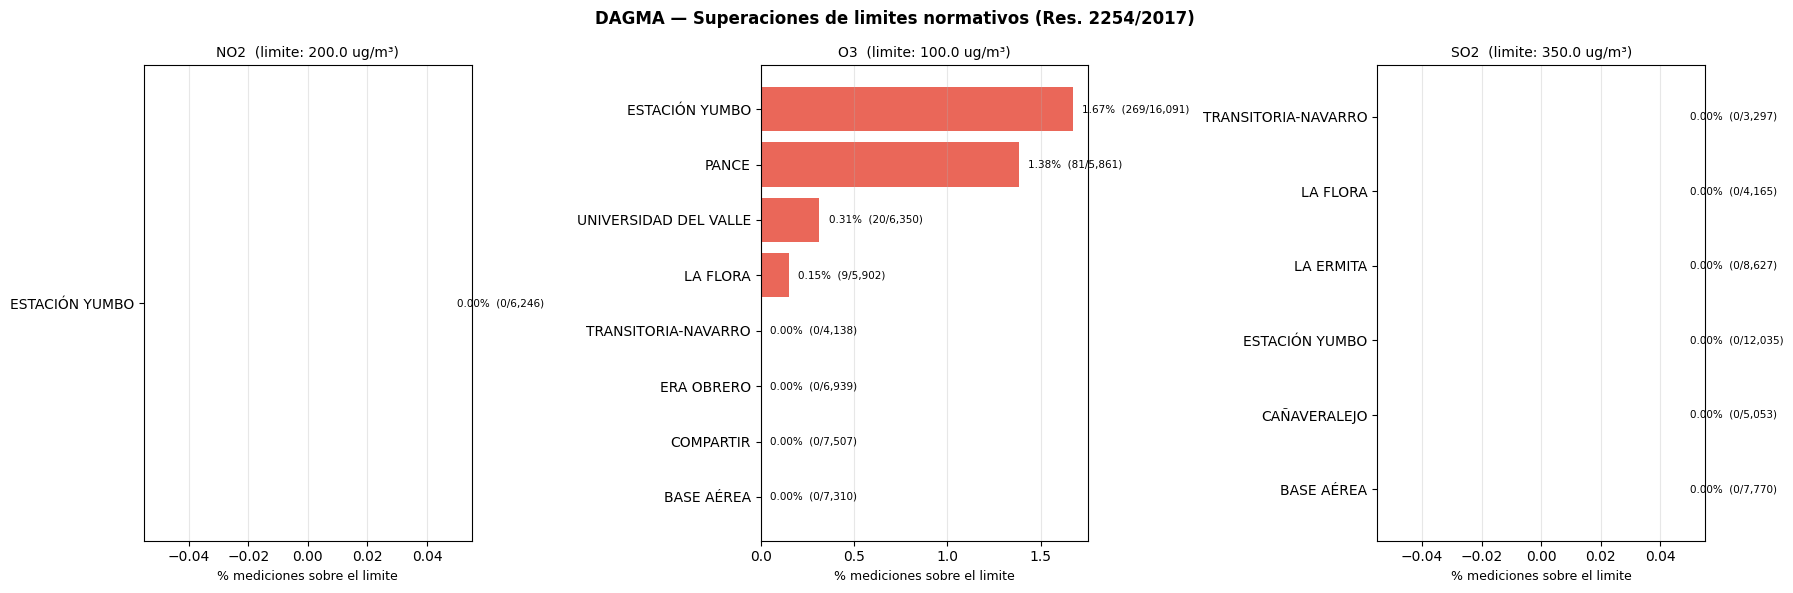

contaminante              estacion      pct  n_exc  n_total
          O3        ESTACIÓN YUMBO 1.671742    269    16091
          O3              LA FLORA 0.152491      9     5902
          O3                 PANCE 1.382017     81     5861
          O3 UNIVERSIDAD DEL VALLE 0.314961     20     6350


In [25]:
excedencias = []
for cont in contaminantes:
    if cont not in LIMITES_NORM:
        continue
    lim = LIMITES_NORM[cont]['limite']
    for est in estaciones:
        vals = df[(df[COL_CONT] == cont) & (df[COL_EST] == est)][COL_CONC].dropna()
        if len(vals) == 0:
            continue
        n_exc = (vals > lim).sum()
        pct   = 100 * n_exc / len(vals)
        excedencias.append({'contaminante': cont, 'estacion': est,
                            'pct': pct, 'n_exc': int(n_exc), 'n_total': len(vals)})

df_exc = pd.DataFrame(excedencias)
cont_exc_list = [c for c in contaminantes if c in df_exc['contaminante'].values]
n_cols = len(cont_exc_list)

fig, axes = plt.subplots(1, n_cols, figsize=(6*n_cols, 6))
fig.suptitle('DAGMA — Superaciones de limites normativos (Res. 2254/2017)',
             fontsize=12, fontweight='bold')
axes = np.array([axes]).ravel() if n_cols == 1 else np.array(axes)

for i, (cont, ax) in enumerate(zip(cont_exc_list, axes)):
    sub = df_exc[df_exc['contaminante'] == cont].sort_values('pct', ascending=True)
    colors = ['#e74c3c' if v > 0 else '#bdc3c7' for v in sub['pct']]
    bars = ax.barh(sub['estacion'], sub['pct'], color=colors, alpha=0.85)
    ax.set_title(f'{cont}  (limite: {LIMITES_NORM[cont]["limite"]} ug/m³)', fontsize=10)
    ax.set_xlabel('% mediciones sobre el limite', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    for bar, (_, row) in zip(bars, sub.iterrows()):
        label = f'{row["pct"]:.2f}%  ({row["n_exc"]}/{row["n_total"]:,})'
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                label, va='center', fontsize=7.5)

plt.tight_layout()
plt.savefig(DIR_FIGS / 'viz8_excedencias.png', bbox_inches='tight')
plt.show()
print(df_exc[df_exc['pct'] > 0].to_string(index=False))

### Análisis Viz 8 — Superaciones de límites normativos

**Solo O₃ presenta excedencias** del límite horario (100 µg/m³, Res. 2254/2017). Cuatro estaciones registraron superaciones: **ESTACIÓN YUMBO** 1.67 % (269/16 091 h), **PANCE** 1.38 % (81/5 861 h), **UNIVALLE** 0.31 % (20/6 350 h) y **LA FLORA** 0.15 % (9/5 902 h). SO₂ y NO₂ tienen 0 % de excedencias — sus picos máximos (241 y 164 µg/m³) quedan bajo sus límites normativos (350 y 200 µg/m³). El O₃ es el **único contaminante de alerta** en Cali 2020-2024; la distribución de eventos en múltiples zonas del sur (PANCE, UNIVALLE) y norte (YUMBO) confirma que no es un problema exclusivamente industrial.

---
## Resumen ejecutivo

In [26]:
print(f'Estaciones     : {len(estaciones)}')
print(f'Contaminantes  : {contaminantes}')
print(f'Total registros: {len(df):,}')
print(f'Rango temporal : {df[COL_FECHA].min().date()} → {df[COL_FECHA].max().date()}')
print(f'NaN eliminados : {df_raw[COL_CONC].isna().sum():,}')
print(f'Figuras        : {sorted(p.name for p in DIR_FIGS.glob("*.png"))}')

Estaciones     : 10
Contaminantes  : ['NO2', 'O3', 'SO2']
Total registros: 107,291
Rango temporal : 2020-01-01 → 2024-12-31
NaN eliminados : 0
Figuras        : ['viz1_mapa_estaciones.png', 'viz2_cobertura.png', 'viz2_cobertura_temporal.png', 'viz3_series_temporales.png', 'viz4_ciclo_diurno.png', 'viz5_climatologia_mensual.png', 'viz6_distribuciones.png', 'viz7_correlacion.png', 'viz8_excedencias.png']
